# Notebook 5: Introduction to the ZPIC particle-in-cell code
## and electron plasma waves

## Submission
The assessed parts of this computing laboratory are due Friday 31st October at 11:59PM.

## Classwork

In this Worksheet 5 we will introduce the 1D electrostatic particle-in-cell code ZPIC by studying the basic electrostatic oscillation modes of a plasma, including thermal effects. We will start by simulating cold plasma waves by perturbing the particle velocities, then generate a travelling wave by perturbing the particle velocities and positions. Finally we will create a thermal distribution and reproduce the Bohm-Gross dispersion relation. 

### Particle-in-cell codes

ZPIC has several versions; electrostatic and electromagnetic, spectral or FDTD solvers, 1D and 2D in space. The code we will use first is ES1D, which is 1D1V. The  structure is similar to ES1, the electrostatic code developed by Birdsall and Langdon in 1972 [1]. Things have obviously changed a lot since then, but the basic structure of most particle-in-cell (PIC) codes is broadly similar. 


As described in lectures, a PIC code is a computational method used to simulate the behavior of charged particles (such as electrons and ions) interacting with electromagnetic fields. In PIC codes, the positions and velocities of particles are tracked individually, while the fields (electric and magnetic) are calculated on a grid—particles deposit their charge and current to the grid, the fields are updated (often using Maxwell’s equations), and then the forces from the fields are interpolated back onto the particles to update their motion, enabling self-consistent plasma and beam simulations. The basic PIC loop is shown in Figure 1.

<div align="center">
  <img src="ls5_figures/PIC_loop.png" alt="picloop" width="400px">

*Figure 1: The basic particle-in-cell loop (credit: Ricardo Fonseca)*

</div>

#### Finite difference equations of motion
The equations of motion are as follows. As a reminder, here the notation for the discrete units is that $n$ refers to time-steps, $i$ to particle index and $j$ to position index on the spatial grid. We can use a leapfrog method to accurately reproduce the particle orbits, provided $\omega\Delta t<1$ (with $\omega$ being the characteristic oscillation timescale). Recall that the leapfrog method has the nice property of being neutral. For a discretized time $t=n\Delta t$, the equations of motion may be written as:
\begin{equation}
v_i^{n+1/2}=v_i^{n-\frac{1}{2}}+ F_i^{n}\Delta t\;,\nonumber
\end{equation}

\begin{equation}
x_i^{n+1}=x_i^{n}+v_i^{n+1/2}\Delta t \;.\nonumber
\end{equation}

Notice that we have exploited the staggered calculations to get a leapfrog differencing scheme but without having to use additional memory storage. The force on a particle $i$, $F_i$ arises from the interpolated fields, in the absence of magnetic field, $F_i=q_iE_i$. The following normalizations are  used: $t\rightarrow \omega_pt$, $x\rightarrow \omega_px/v_0$, $v_i\rightarrow v_i/v_0$, $E\rightarrow eE/mv_0\omega_p$, $\phi\rightarrow e\phi/mv_0^2$, $\delta \rho\rightarrow \delta \rho/en_0$, where $n_0 = \omega_p^2m\varepsilon_0/e^2$.

#### The field solver
To calculate the fields on the grid ES1D exploits the fast Fourier transform to turn our differential equations into  algebraic equations. The discrete Fourier transform of the finite difference representation of Poisson's equation is:

\begin{equation}
k_j^2\tilde{\phi}_j=\delta \tilde{\rho}_j\;,\nonumber
\end{equation}

where the tilde indicates a Fourier transformed quantity and $k_j$ are the wavenumbers on the grid with spacing $\Delta x$ ($k_j$ are in integer multiples of $\pi/N_x\Delta x$). The basic algorithm is
 
* Transform $\rho_j^n$ to $\tilde{\rho}_j^n$ using an FFT.
*  Calculate $\tilde{\phi}_j^n$ using 
\begin{equation}
\tilde{\phi}_j^n=\frac{\delta \tilde{\rho}^n_j}{K_j^2}\;.\nonumber
\end{equation}
*  Calculate $\tilde{E}_j^n$ using 
\begin{equation}
\tilde{E}_j = -i\kappa_j\tilde{\phi}_j^n\;,\nonumber
\end{equation}
* Transform $\tilde{E}_j^n$ to $E_j^n$ to  using the inverse FFT.

This is not the only way of performing this calculation using the FFT. Another way is to calculate the electric field  $E$ directly from the density distribution using a similar relationship or even by using the wavenumber $k_j{\rm sinc }(k_j\Delta x) $ instead of $k_j$ (for a discussion on the distinction between these, see Birdsall and Langdon appendix E [1]). However, the current method using $\phi$ has the advantage of being easily extendable to any number of dimensions and makes diagnosis of field energy easier. 

#### Particle charge weighting scheme
We now consider  how the two spaces are related, i.e. the space of particles $i$ and spatial grid space $j$. For first order weighting, as used in the standard ZPIC algorithm, the particle charge is linearly weighted between the two neighboring grid-points nearest the particle, $j$ and $j+1$, as described in  lectures, as:
\begin{equation}
\delta\rho_j=\left(\frac{X_{j+1}-x_i}{\Delta x}\right)W\quad\quad \delta\rho_{j+1}=\left(\frac{x_{i}-X_j}{\Delta x}\right)W\;.\nonumber
 \end{equation}

#### Mapping the fields to the particles
The final stage is to map the gridded fields to the particles. In  lectures we saw  why the same weighting process must be used for mapping the particles to the grids as mapping the forces to the particles, otherwise {\it fictitious forces} arise as a result. We want to map from $E_j^n$ to $F_i^n$. To do this, for first order weighting the force at particle $i$ between two grid points at $x_j$ and $x_{j+1}$ is given by:
\begin{equation}
F_i=\left(\frac{x_{j+1}-x_i}{\Delta x}\right)E_j+\left(\frac{x_i-x_j}{\Delta x}\right)E_{j+1}\;.\nonumber
 \end{equation}
The nearest neighbors for each particle, $j$ and $j+1$, can be found in the same way as mapping from the particle positions to the grid.

### References
[1] C. K. Birdsall and A. B. Langdon, Plasma Physics via Computer Simulation, Inst. Phys. Series in Plasma Physics, Taylor and Francis Group, LLC (2005).

## Running ZPIC from Python

ZPIC includes a Python interface allowing you to run simulations directly from a Python environment. This can be done interactively from a console or notebook, or from a Python script.

To run a ZPIC simulation from Python you must do the following:
1. Select the ZPIC version you will be using for the simulation (em2d, em1ds, etc.)
2. Initialize the simulation parameters
3. Run the simulation

### 1. Selecting the ZPIC version to use

Selecting the ZPIC version to use is done by importing the appropriate module. We will be using the 1D electrostatic code, ES1D, in this example so we need to import the `es1d` module. We also load other libraries we will use.

In [1]:
# Libraries needed for this worksheet
import numpy as np
import matplotlib.pyplot as plt
# Add zpic library to path
import sys
sys.path.append("../../lib")


import es1d
import lshelper as ls5


### Part 1: Cold plasma waves

Plasma waves are arguably the most fundamental form of plasma behavior. We will study plasma waves in one dimension, starting with a linearized model for plasma oscillations. The initial test of the code's capabilities will be to examine *cold, linear* plasma waves. After this we can examine a more general plasma wave form to look at in our particle-in-cell codes that is difficult to solve analytically. We also have the capacity to do many particles per cell with our codes, which means we can use a Maxwellian velocity distribution to launch thermal plasma waves (which have a different  dispersion function). 


Strictly speaking, the particles in our simulations are not particles but are charge sheets with infinite extent in the plane perpendicular to
our dimension. Likewise, a 2-D simulation would involve infinite length rods. It is worth bearing this in mind when interpreting results from the code. 
The number density of particles is a bit odd, because one would normally think of it in terms of the number of particles divided by a volume, but we don't 
have the other two dimensions. Instead, you can imagine the number density of uniformly distributed particles to be:
\begin{equation*}
n_0=\sigma_0\times \frac{N}{L}\;,
\end{equation*}

where $N$ is the total number of particles or charge sheets, $L$ is the length of the system and $\sigma_0$ is the charge areal density. In other words, the charge sheet represents the density of particles in the plane transverse to the system. As an example, you could think of the charge sheet as being a large wire mesh with magnetic balls stuck to it, so that the balls are free to move randomly in the plane of the mesh, but must move with the mesh as it moves back and forth. In normalization, $\sigma_0$ will probably be normalized out so that it is a factor 1, but it does pay to be aware of this fact from a dimensionality point of view.

In the one-dimensional "charge-sheet" model [2], provided charge sheets do not cross, electrons oscillate collectively at a frequency dependent only on the local electron number density and temperature (Actually this is not strictly true, for example, relativistic effects can change the oscillation frequency). The simplest example of oscillations is cold linear electron plasma waves, that is to say $T=0$, which also means the electron pressure is zero. To launch cold plasma waves, we essentially extend the simple harmonic motion of the two particles to many particles. This is actually a fundamental fact about plasma waves; not only does the plasma density perform simple harmonic motion, but all the particles also perform simple harmonic motion about their initial positions. In fact, even in the case of non-linear plasma waves, where the plasma density oscillation can be *far from sinusoidal*, the interesting thing is that each particle in the wave *does* perform simple harmonic oscillations. In this case, the particles all oscillate at the plasma frequency, provided the ordering of particles is maintained, i.e. the charge sheets do not cross \[2\].

Consider the analytic solution for cold plasma waves; if we take the continuity equation for an electron fluid with number density $n_e$ and velocity $u$ in one dimension:
$$\frac{\partial n_e}{\partial t} = -\frac{\partial}{\partial x} \left(n_e u\right)\;,$$
along with the  electric force on a fluid element:
$$m_en_e\frac{\partial u}{\partial t} = -eE\;,$$
and Gauss's law in the presence of a neutralizing ion background $n_0$:
$$\frac{\partial E}{\partial x} = -e(n_e-n_0)\;,$$
We can linearize and combine these equations to obtain a simple harmonic motion equation
$$\frac{\partial^2 }{\partial t^2} \delta n_e= -\frac{e^2n_0}{m_e\epsilon_0} \delta n_e\;,$$
 with characteristic frequency; the electron plasma frequency $\omega_p = \sqrt{{e^2n_0}/{m_e\epsilon_0}}$. We can write down an Ansatz solution to this equation:
$$ \delta n_e = \delta n_{e0}\left(Ae^{i (k_p x-\omega_pt)}+Be^{i (-k_p x-\omega_pt)}\right) + cc\;,$$
where $A$ and $B$ are constants, $cc$ indicates the complex conjugate and  $k_p$ is the plasma wavenumber, which is related to the wavelength of an oscillation $\lambda_p$ by $k_p=2\pi/\lambda_p$. Note that we have introduced $k_p$, but $x$ is not present in the simple harmonic oscillator equation. In this case $k_p$ is completely arbitrary. 

To understand what this waveform represents, let's examine a specific solution. Choosing $A=1/2$, $B=0$, we can rewrite the above solution in terms of $v_p=\omega_p/k_p$,
$$ \delta n_e = \tfrac{1}{2}\delta n_{e0}e^{i (k_p (x-v_p t)} + cc\;.$$
In this case, we can observe that the wave is a function of a single variable $\xi=x-v_pt$ only, which represents the phase of a traveling wave. By performing a coordinate transform into a  co-moving frame with speed $v_p=\omega_p/k_p$, $x^\prime = x - v_pt \equiv \xi$, the solution is just a static sinusoid in the moving frame. This is known as a traveling wave solution. 

A different type of behavior is obtained if we choose $A=1/4$, $B=1/4$. In this case we can reduce the solution to 
$$\delta n_e = \delta n_{e0}\cos k_p x \sin \omega_pt\;.$$
At $t=0$ this is a sinusoid in space. As we then cycle through time, the overall amplitude of the wave simply increases and decreases, but the position of a maxima/minima never shifts. This is known as a standing wave. An illustration of this wave is shown in figure 2.

<div align="center">
  <img src="ls5_figures/new_test1.png" alt="new_test1" width="600px">

*Figure 2: The density perturbation $\delta n/n_0$ and electric field $eE/m_ec\omega_p$ of a standing wave (color scale) as a function of time $\omega_pt$ and space $k_p x$*

</div>



### References
[2] J.M.~Dawson, Phys. Rev. (1959)

#### A first simulation with ZPIC

We will go through running a first simulation with ZPIC to generate cold plasma waves. To do this, we will generate a uniform density of electrons and then perturb their velocities using a spatially dependent perturbation. We will then be able to visualize the oscillations as a function of space and time as in Figure 2 above. First we initialize the simulation:


### 2. Initializing simulation parameters

As in any ZPIC simulation, we will need to set the particle species parameters, grid, and timestep  to be used for the simulation. For our example we will be using a single electron species with 1 particle per cell.

Each of the species will be an instance of the `e1sd.Species` class:

In [19]:
# Simulation parameters
nx = 128            # Number of grid cells
box = 2.0 * np.pi   # Length of the box
dt = 0.05           # Time step
ppc = 1             # Particles per cell
tmax = 20.0 * np.pi # Maximum time of the simulation

q_e = -1.0           # Electron charge

# Initialize the species
electrons = es1d.Species( "electrons", q_e, ppc)

# Initialize the simulation
sim = es1d.Simulation( nx, box, dt, species = electrons)


#### Implementing wave perturbations in the particle-in-cell code
For a non-uniform distribution, the charge density at a point $x$ can be found by considering 2 adjacent particles (charge sheets) in the system, at points $x_1$ and $x_2$, in a uniform plasma. The charge density can also be expressed as: 
\begin{equation*}
n_0=\frac{\sigma_0}{x_1-x_2}\;.
\end{equation*}
Now, if the particle positions are perturbed by a small amount $\delta x_1$ and $\delta x_2$ so that the plasma is non-uniform, the number density at position 
$x\approx (x_1+x_2)/2$ is given by:
\begin{equation*}
n(x)=\frac{\sigma_0}{x_1+\delta x_1-x_2-\delta x_2}
=\frac{n_0}{1+\frac{\delta x_1-\delta x_2}{x_1-x_2}}\;.
\tag{(1)} 
\end{equation*}
Provided $x_1$ and $x_2$ are very close, we can approximate the difference in the denominator as a derivative:
\begin{equation*}
\frac{\delta x_1-\delta x_2}{x_1-x_2}\cong \frac{d \delta x}{dx}\;,
\end{equation*}
and rearrange equation 1 to obtain:
\begin{equation*}
\frac{d \delta x}{dx}=\frac{n_0-n(x)}{n(x)}\simeq -\frac{\delta n}{n_0}\;,
\tag{(2)}
\end{equation*}
where $\delta n=n_0-n(x)$.

To launch cold plasma waves in your system, there are a few things to be aware of. Firstly, one must initialize the particle positions and velocities. Assuming the particles are distributed uniformly initially, small spatially dependent perturbations to these positions must be added to achieve a coherent wave structure. Assuming we want to launch a wave with wave-number $k_p$ and amplitude $\delta n_0$ so that:
\begin{equation*}
n(x) = n_0+\delta n_0 \sin(k_p x)\;,
\end{equation*}
Then, the particle displacements can be calculated by integrating equation 2, so that:
\begin{equation*}
\delta x(x) = -\int \frac{\delta n_0}{n_0} \sin(k_p x)dx = \frac{\delta n_0}{n_0k_p} \cos(k_p x)\;.
\end{equation*}
To get the particle initial velocities, we can consider the continuity equation for the particles in one dimension:
\begin{equation*}
\frac{\partial  n}{\partial t}+\frac{\partial (nv)}{\partial x}=0\;.
\end{equation*}
For a wave moving with phase velocity $v_p = \omega_p/k_p$, in the frame $\xi=x-v_pt$, the wave will be a stationary structure (consider flying along in a helicopter above some waves, if you travel at the same speed as the wave then the structure will appear not to change). Using this change of coordinates, the continuity equation is:
\begin{equation*}
-v_p\frac{d  n}{d\xi}+\frac{d(nv)}{d\xi}=0\;.
\end{equation*}
By integrating this we obtain:
\begin{equation*}
n=\frac{n_0}{1-\frac{v}{v_p}}\;,
\end{equation*}

\begin{equation*}
v(x)=v_p\left(1-\frac{n_0}{n(x)}\right)\simeq v_p\frac{\delta n}{n_0}\;.
\end{equation*}
Hence, the particle velocities can be initialized as $v_p\delta n_0/n_0\sin(k_p x)$ to obtain a wave traveling with phase velocity $v_p=\omega_p/k_p$. 


<div style="background-color: #013220" > 
<span style="color:white;">

**Exercise 1: Generate a small perturbation with a wavenumber $k_p=1$ in the electron velocities to initialize a plasma wave with amplitude $\delta n_0=0.01$ and visualize this in phasespace to confirm.**

</span>


In [20]:
# This helper function obtains the particle positions in the full simulation box xi
# Note that the particles are stored in cell number "ix" with relative position offset 
# "x" in the cell, so the actual position is (ix + x) * dx which this function returns
xi = ls5.xpos(electrons)

# Initialize the particle velocities to obtain a wave with density perturbation
#  magnitude delta_n0 = 0.01 and a sinusoidal perturbation
delta_n0 = 0.01
kp = 1.0  # Wavenumber of the perturbation
delta_v0 = delta_n0*1.0/kp
electrons.particles['vx'] += delta_v0 * np.sin(kp* xi) #<code here>

# Perturb the initial particle positions 
electrons.particles['x'] += 0 

Here, we visualize the initial particle distribution in $x-v_x$ phasespace to confirm it is initialized correctly.

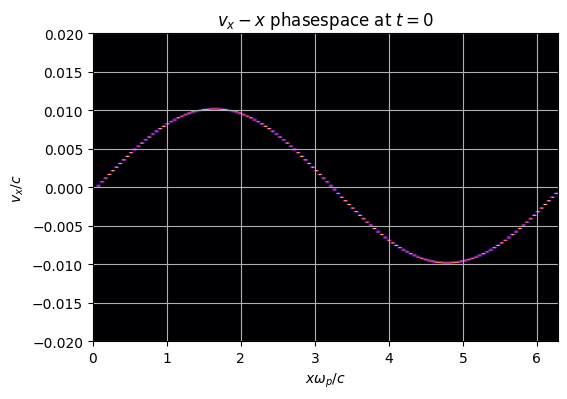

In [21]:
# Plot the initial particle distribution
ls5.plot_phase_space(sim, electrons,[sim.nx,256], (0,box),(-2*delta_v0,2*delta_v0))

<div style="background-color: #013220" > 
<span style="color:white;">

**Exercise 2: Generate a function `run_chg_E_time(sim,tmax)` that runs the simulation until `tmax` and stores the charge density and electric field as an array representing their variation in both time (horizontal) and space (vertical).**

We can obtain the charge density using `sim.charge.rho` and the electric field data using `sim.field.E`

ZPIC can run the full simulation using `sim.run(<time>)` but here we will use the method `sim.iter()`, which will execute one iteration of the code. By looping up to `tmax`, you can extract the charge density and electric field at each timestep.
</span>


In [22]:
#This function will run the simulation and create data arrays for charge and field
def run_chg_E_time(sim, tmax):
    charge_data_time = (sim.charge.rho)
    E_data_time = (sim.field.E)
    while (sim.t<tmax):
        sim.iter()
        charge_data_time = np.vstack((charge_data_time,sim.charge.rho))
        E_data_time = np.vstack((E_data_time,sim.field.E))
    return np.rot90(charge_data_time), np.rot90(E_data_time)


We execute our function and then plot the results using the helper function `ls5.plot_field_and_charge(sim, charge_data_time, E_data_time, tmax)`, which expects the `charge_data_time` and `E_data_time` arguments to be orientated as in Figure 2.

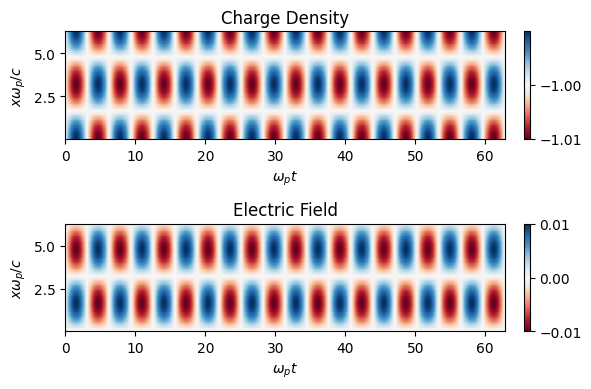

In [23]:
charge_data_time, E_data_time = run_chg_E_time(sim, tmax)
ls5.plot_field_and_charge(sim, charge_data_time, E_data_time, tmax)

<div style="background-color: #013220" > 
<span style="color:white;">

**Exercise 2: Now generate a small perturbation with a wavenumber $k_p=1$ in the electron velocities to initialize a plasma wave with amplitude $\delta n_0 = 0.01$ that is traveling with a phase velocity of**

(a) $v_p = 1$.

(b) $v_p = 2$. 

Confirm this visually; if correctly initialized the wave in part (a) should look like Figure 3, i.e. with a slope of +1 in $x-t$ space.

</span>

</div>

<div align="center">
  <img src="ls5_figures/new_test2.png" alt="new_test1" width="600px">

*Figure 3: The density perturbation $\delta n/n_0$ and electric field $eE/m_ec\omega_p$ of a traveling wave (color scale) as a function of time $\omega_pt$ and space $k_p x$*
</div>


In [ ]:
# Re-initialize the simulation - we must do this every time we want to re-run
sim = es1d.Simulation( nx, box, dt, species = electrons)

# This helper function obtains the particle positions in the full simulation box xi
# Note that the particles are stored in cell number "ix" with relative position offset 
# "x" in the cell, so the actual position is (ix + x) * dx which this function returns
xi = ls5.xpos(electrons)

# Initialize the particle velocities to obtain a wave with density perturbation
#  magnitude delta_n0 = 0.01 and a sinusoidal perturbation
delta_n0 = 0.01

electrons.particles['vx'] += delta_v0 * # <code here>

# Now perturb the initial particle positions to obtain a traveling wave!
# Note that the particles are stored in cell ix with position offset x in the cell
# So the actual position is (ix + x) * dx

electrons.particles['x'] += delta_x0 * # <code here>



In [ ]:
charge_data_time, E_data_time = run_chg_E_time(sim, tmax)
ls5.plot_field_and_charge(sim, charge_data_time, E_data_time, tmax)

## Part 2: Non-linear plasma waves 
We have compared with linearized analytic theory, but one thing the particle-in-cell code can do well is handle highly nonlinear physics. For example, if the particle displacements are large we get a non-linear plasma wave. For a one-dimensional density perturbation of magnitude $\delta n_0/n_0$, the electron density $n(x)$ can then be expressed as a perturbative solution [3]  
$$ n(x) = n_0\sum_m \frac{m^m}{2^{m-1} m!}\left(\frac{\delta n_0}{n_0}\right)^m\cos\left(m k_px\right)\;.$$

Clearly, for  $\delta n_0/n_0\rightarrow 0$, this reduces to the linear result. For larger density perturbations, \emph{harmonics} of the fundamental mode become significant. However, counterintuitively each particle (charge sheet) still oscillates at $\omega_p$ despite the nonlinear shape of the wave (figure 4).

<div align="center">
  <img src="ls5_figures/nonlin.png" alt="nonlin" width="600px">

*Figure 4: A nonlinear plasma wave.*
</div>

### Wavebreaking

When the wave amplitude exceeds a certain threshold, the particle sheets cross and the wave structure loses coherence. This is known as ``wave breaking''. John Dawson showed [2] that the charge sheets could be described by a trajectory that is simple harmonic motion about an equilibrium position $x_0$ such that their positions were given by $x=x_0+X$, with $X$ given by 
$$\frac{d^2X}{dt^2} = -\omega_{p0}^2X\;,$$
with one possible solution being $X=A\sin kx_0$ with amplitude $A$. The electric field is $E=(en_0/\epsilon e_0)A\sin kx_0$. Figure 5, taken from his paper, shows the effect of larger amplitude oscillations on the electric field. Note that if $A>1/k$, i.e. the excursion of a single electron is larger than the wavelength of the wave, the solution is multivalued, which corresponds to trajectory crossing. When the wave breaks, particles tend to get trapped in the wave, and so wave energy gets transferred to the particles. 

<div align="center">
  <img src="ls5_figures/dawsonfig.png" alt="dawsonfig" width="400px">

*Figure 5: The electric field, $E/E_{max}$ as a function of $x$ for various values of $A$, of a nonlinear plasma wave, from J. M. Dawson, Phys. Rev. (1959).*
</div>

#### References
[3] E. A. Jackson, Nonlinear Oscillations in a Cold Plasma, Phys. Fluids 3, 831 (1960).

<div style="background-color: #013220" > 
<span style="color:white;">

**Exercise 3: Generate a cold plasma wave with a *large* perturbation.**

* Start with  $\delta n =0.25$. Confirm that the structure still oscillates at $\omega_p$ despite the spatial non-linearity. 
* Can you get agreement between the non-linear wave in your particle-in-cell code and the solution above? Compare the analytic and numerical solutions directly. Does it work for $\delta n =0.5$? $\delta n =0.75$?
* Can you get wavebreaking if the wave amplitude is initiated with sufficiently large amplitude? (Initialize a traveling wave and consider the velocity perturbation of the individual electrons compared to the phase velocity of the wave) 




In [ ]:
# Suggested initial simulation parameters
nx = 256
box = 8.0 * np.pi
dt = 0.05
ppc = 100
tmax = 0.5*np.pi

# Initialize the species
electrons = es1d.Species( "electrons", -1.0, ppc)

sim = es1d.Simulation( nx, box, dt, species = electrons)

x = ls5.xpos(electrons)

# Initialize the particle velocities

# <code here>

We can then run the simulation in a different way by using `sim.run(tmax)` which runs the simulation up to `tmax`, but we will only have access to the fields at the final time.

In [ ]:
# Run the simulation
sim.run(tmax)

In [ ]:
# Write code here to compare the simulation results with the nonlinear analytic solution
# generate a figure like Figure 4



### Part 3: Warm plasma waves

When we have a thermal distribution, the dispersion relation for linear plasma waves is modified. The full linear dispersion relation can be calculated from
$$\epsilon =  1+\frac{q^2}{km\epsilon_0}\int\frac{1}{\omega-kv}\frac{\partial f_0}{\partial v} dv=0\;,$$
This contains some interesting effects, including that of the singularity at $\omega = kv$, which we will cover later. For a fast phase velocity and not too wide thermal distribution, it can be shown that including the first two non zero terms of an expansion of the denominator, and assuming a Maxwellian velocity distribution, leads to the dispersion relation for thermal plasma waves, known as the Bohm-Gross relation:
$$\omega^2=\omega_{p0}^2+3k^2v_{th}^2\;,$$
where $v_{th} = \sqrt{k_BT/m}$ is the thermal velocity. These waves can also be launched in your code by starting with a thermal distribution and then adding a perturbation to the particle velocities/positions as for the cold plasma case to launch a wave. Note that the dispersion relation adds some extra constraints owing to the explicit $k$ dependence.

 To represent a thermal distribution 
$$f(v) = \frac{1}{\sqrt{2\pi}v_{th}}e^{-v^2/2v_{th}^2}\;, $$
with a limited number of particles. We ideally need to distribute particles such that they are uniformly distributed in both space and velocity space with no correlations between particles, because these will show up in the distribution. Here, the thermal distribution is represented by randomly sampling particle velocities from a gaussian distribution.


 <div style="background-color: #013220" > 
<span style="color:white;">

**Exercise 4: Visualize a thermal distribution. Launch a thermal plasma wave and show that it obeys the Bohm-Gross relation.**

* Visualize the distribution function by making a `histogram` of the particle velocities. Directly compare with the analytic maxwellian distribution and confirm it has the correct form.
* Initiate a thermal *standing* plasma wave. Suggested parameters $NPPC=1024$, $N_x=256$, $\delta\rho = 0.05$, $k_p=20$, $v_{th}=0.0125$, where $NPPC$ is the number of particles \emph{per cell}, $N_x$ is the number of grid points, $\delta\rho$ is the perturbation amplitude, $k_p=20$ and $v_{th}=0.0125$. Run to a maximum time $t_{max}=20\pi$.
* Show it obeys the Bohm-Gross relation. (Hint: Fourier analysis, make a $k-\omega$ phasespace and plot dispersion relation).
* Launch a thermal *traveling* plasma wave with a phase velocity of 
    (a) $v_p = 1.0$
    (b) $v_p = 0.5$

    (Hint: You have to think about the dispersion relation constraint and what it means for $k_p$.)
</span>

</div>

Add cells below for these tasks as needed.



In [ ]:

# Simulation parameters
nx = 256
kp = 20.0
box = 2.0*np.pi
dt = 0.05
ppc = 1024

vth = 0.0125

tmax = 40*np.pi/np.sqrt(1.0 + 3*vth**2 * kp**2)


# Initialize the species - vth is the thermal velocity
# and adds a normally distributed random number to the particle 
# velocities scaled  by vth
electrons = es1d.Species( "electrons", -1.0, ppc, vth=vth)


# Code here